Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- [Analysis 1] Delivery Delay vs Review Score ---
is_late
False    4.208401
True     2.257306
Name: review_score, dtype: float64


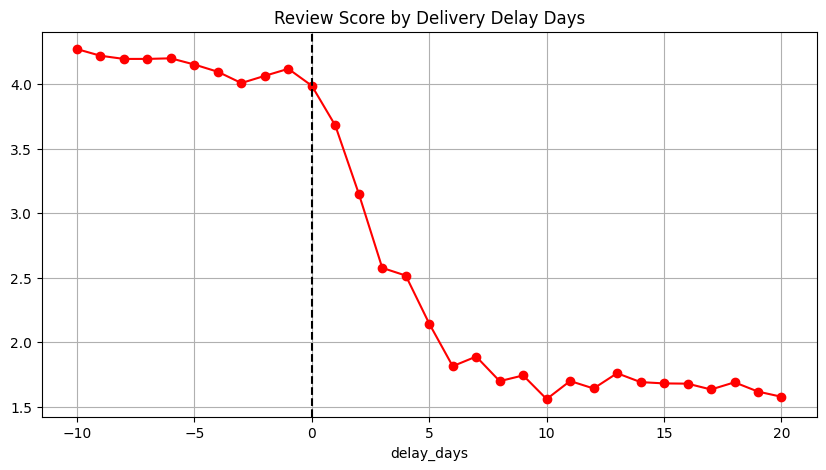


--- RFM Customer Segmentation ---
Total Late Orders: 7264
Critical Managed VIPs (Late & High Score): 1441 orders


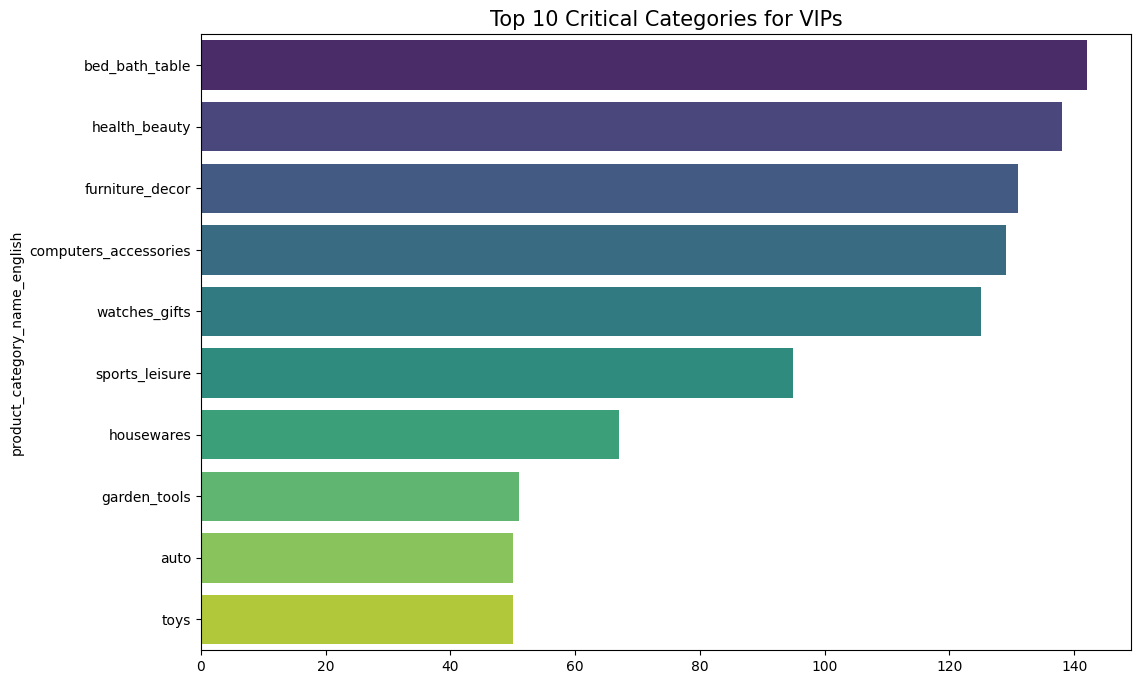

지연을 겪은 VIP 고객들의 총 결제 가치: 415,965.64 BRL

--- [CRM Insight] 지연 여부에 따른 VIP 평균 재구매 횟수 비교 ---
         Customer_Count  Avg_Purchase_Freq
is_late                                   
False             14559           1.297612
True               1144           1.256072


/tmp/ipykernel_2409/3652666444.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vip_all_group, x='is_late', y='Frequency', palette='coolwarm')


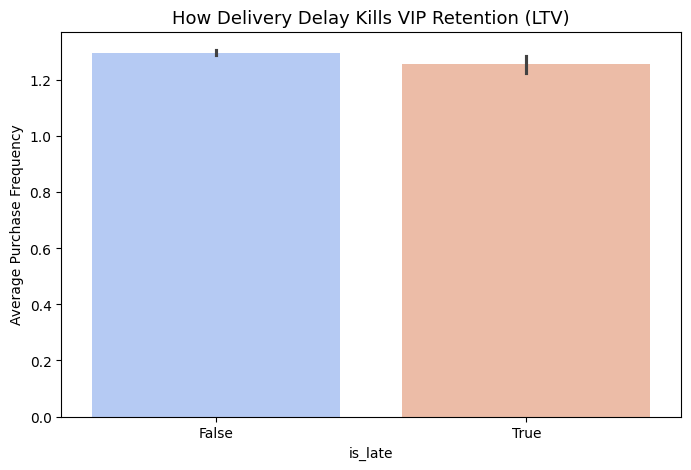


--- [CRM Strategy] Recovery Campaign ROI Simulation ---
예상 집행 비용: 21,615.00 BRL
방어 예상 매출: 83,193.13 BRL
예상 ROI: 3.85배

--- [Final Target List Sample] CRM 개인화 오퍼 ---
                 customer_unique_id risk_level  \
0  ddf60e20e6e262e2136801ce5cd628b0    Warning   
1  ddf60e20e6e262e2136801ce5cd628b0    Warning   
2  b854c56e1163bced9c3ebf1e4a6576f3    Warning   
3  ea870f4fdfd85ac98ab775b76efe3143    Warning   
4  dc184f142552a38189d5d5428d1984a6   Critical   

                       personalized_message  
0           [telephony] 지연 안내: 감사 10% 쿠폰 발송  
1           [telephony] 지연 안내: 감사 10% 쿠폰 발송  
2        [garden_tools] 지연 안내: 감사 10% 쿠폰 발송  
3          [cool_stuff] 지연 안내: 감사 10% 쿠폰 발송  
4  [watches_gifts] 지연 사과: VIP 20% 특별 할인권 발송  
--- 배송 경험별 VIP 재구매율(Retention Rate) ---
정시 배송 시 재구매율: 22.72%
지연 배송 시 재구매율: 21.51%
지연으로 인한 리텐션 하락폭: 1.21%p


/tmp/ipykernel_2409/3652666444.py:174: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=retention_kpi.index, y=retention_kpi.values, palette='Set2')


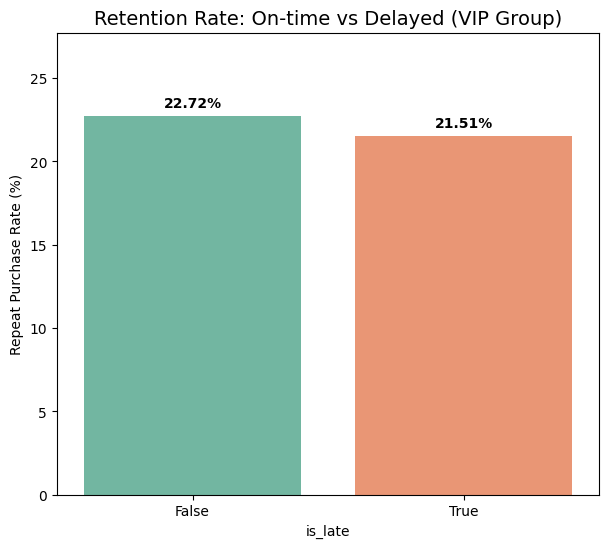


--- 캠페인 시나리오별 ROI 시뮬레이션 ---
    Scenario  Coupon(BRL)  Conv_Rate(%)  Total_Cost  Defended_Revenue  ROI
Conservative           10          15.0       14410          62394.85 4.33
        Base           15          20.0       21615          83193.13 3.85
  Aggressive           20          25.0       28820         103991.41 3.61


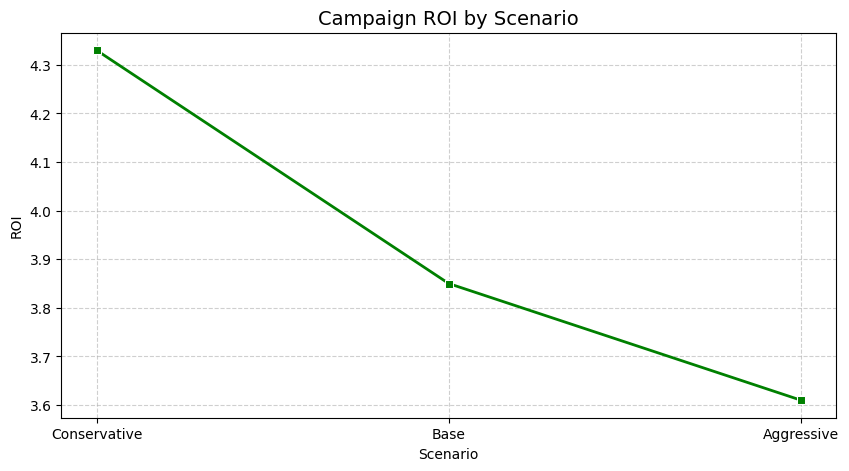

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

# 데이터 로드 및 통합 병합
drive.mount('/content/drive')
path = '/content/drive/MyDrive/project2/'

def load_and_merge():
    orders = pd.read_csv(path + "olist_orders_dataset.csv")
    items = pd.read_csv(path + "olist_order_items_dataset.csv")
    payments = pd.read_csv(path + "olist_order_payments_dataset.csv")
    customers = pd.read_csv(path + "olist_customers_dataset.csv")
    reviews = pd.read_csv(path + "olist_order_reviews_dataset.csv")

    # 1:N 관계 집계 (결제금액, 리뷰점수)
    pay_agg = payments.groupby("order_id")["payment_value"].sum().reset_index()
    rev_agg = reviews.groupby("order_id")["review_score"].mean().reset_index()

    # orders 기준으로 병합 (데이터 손실 방지)
    df = orders.merge(customers, on="customer_id", how="left")
    df = df.merge(pay_agg, on="order_id", how="left")
    df = df.merge(rev_agg, on="order_id", how="left")
    df = df.merge(items, on="order_id", how="left")

    return df

df = load_and_merge()

# 전처리 (날짜 변환 및 지연 지표 생성)
date_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# 배송 완료된 데이터만 분석
df_del = df[df['order_status'] == 'delivered'].copy()

# 지연 일수 및 여부 계산
df_del['delay_days'] = (df_del['order_delivered_customer_date'] - df_del['order_estimated_delivery_date']).dt.days
df_del['is_late'] = df_del['delay_days'] > 0

# 배송 지연이 만족도에 미치는 영향
print("--- [Analysis 1] Delivery Delay vs Review Score ---")
print(df_del.groupby('is_late')['review_score'].mean())

# 시각화: 지연 일수별 평균 별점 추이
delay_summary = df_del[(df_del['delay_days'] >= -10) & (df_del['delay_days'] <= 20)]
delay_plot = delay_summary.groupby('delay_days')['review_score'].mean()

plt.figure(figsize=(10, 5))
delay_plot.plot(marker='o', color='red')
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Review Score by Delivery Delay Days')
plt.grid(True)
plt.show()


# RFM 고객 세분화
print("\n--- RFM Customer Segmentation ---")
snapshot_date = df_del['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# RFM 산출 (customer_unique_id 기준)
rfm = df_del.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# 스코어링 (1~5점)
rfm['R'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])
rfm['RFM_Score'] = rfm[['R', 'F', 'M']].astype(int).sum(axis=1)


# 지연을 경험한 우수 고객(VIP) 추출 및 카테고리 분석
# 모든 지표(Frequency 포함)를 원본에 병합
df_final = df_del.merge(rfm[['Frequency', 'RFM_Score']], on='customer_unique_id', how='left')

# VIP 기준: 상위 20% (예: 12점 이상)
vip_late = df_final[(df_final['RFM_Score'] >= 12) & (df_final['is_late'] == True)].copy()

print(f"Total Late Orders: {df_del['is_late'].sum()}")
print(f"Critical Managed VIPs (Late & High Score): {len(vip_late)} orders")

# 카테고리 테이블 로드 및 병합
products = pd.read_csv(path + "olist_products_dataset.csv")
category_trans = pd.read_csv(path + "product_category_name_translation.csv")

if 'product_category_name' not in vip_late.columns:
    vip_late = vip_late.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')

vip_late = vip_late.merge(category_trans, on='product_category_name', how='left')

# 카테고리 시각화 (Top 10)
top_10_late = vip_late['product_category_name_english'].value_counts().head(10)
plt.figure(figsize=(12, 8))
sns.barplot(x=top_10_late.values, y=top_10_late.index, hue=top_10_late.index, palette='viridis', legend=False)
plt.title('Top 10 Critical Categories for VIPs', fontsize=15)
plt.show()

# 매출 가치 분석
lost_revenue_potential = vip_late['payment_value'].sum()
print(f"지연을 겪은 VIP 고객들의 총 결제 가치: {lost_revenue_potential:,.2f} BRL")

# 지연이 VIP 재구매(Retention)에 미치는 영향 분석
# 전체 VIP 그룹 생성 (지연 경험자 vs 미경험자 비교)
vip_all_group = df_final[df_final['RFM_Score'] >= 12].copy()

# 지연 여부에 따른 평균 재구매 횟수(Frequency) 집계
retention_stats = vip_all_group.groupby('is_late').agg({
    'customer_unique_id': 'nunique',
    'Frequency': 'mean'
}).rename(columns={'customer_unique_id': 'Customer_Count', 'Frequency': 'Avg_Purchase_Freq'})

print("\n--- [CRM Insight] 지연 여부에 따른 VIP 평균 재구매 횟수 비교 ---")
print(retention_stats)

# 시각화: LTV(생애 가치) 하락 증명
plt.figure(figsize=(8, 5))
sns.barplot(data=vip_all_group, x='is_late', y='Frequency', palette='coolwarm')
plt.title('How Delivery Delay Kills VIP Retention (LTV)', fontsize=13)
plt.ylabel('Average Purchase Frequency')
plt.show()

# 이탈 방지(Recovery) 캠페인 ROI 시뮬레이션 및 오퍼 설계
total_late_vips = len(vip_late)
avg_order_val = vip_late['payment_value'].mean()

# 시나리오: 인당 15 BRL 쿠폰 지급 / 20% 재구매 전환 가정
campaign_cost = total_late_vips * 15
defended_revenue = (total_late_vips * 0.20) * avg_order_val

print("\n--- [CRM Strategy] Recovery Campaign ROI Simulation ---")
print(f"예상 집행 비용: {campaign_cost:,.2f} BRL")
print(f"방어 예상 매출: {defended_revenue:,.2f} BRL")
print(f"예상 ROI: {defended_revenue / campaign_cost:.2f}배")

# 개인화 타겟 리스트 생성
vip_late['risk_level'] = vip_late['delay_days'].apply(lambda x: 'Critical' if x >= 7 else 'Warning')

def generate_crm_msg(row):
    cat_name = row['product_category_name_english'] if pd.notnull(row['product_category_name_english']) else 'General'
    if row['risk_level'] == 'Critical':
        return f"[{cat_name}] 지연 사과: VIP 20% 특별 할인권 발송"
    else:
        return f"[{cat_name}] 지연 안내: 감사 10% 쿠폰 발송"

vip_late['personalized_message'] = vip_late.apply(generate_crm_msg, axis=1)

print("\n--- [Final Target List Sample] CRM 개인화 오퍼 ---")
print(vip_late[['customer_unique_id', 'risk_level', 'personalized_message']].head())

# KPI 정교화: 재구매율(Retention Rate) 기반 코호트 비교
# 재구매 여부(Is_Retained) 정의: 구매 횟수가 2회 이상인 고객
rfm['Is_Retained'] = rfm['Frequency'] > 1

# df_final에 재구매 여부 다시 매핑
df_final = df_final.merge(rfm[['Is_Retained']], on='customer_unique_id', how='left')

# 지연 여부에 따른 실제 재구매율(%) 계산
retention_kpi = df_final[df_final['RFM_Score'] >= 12].groupby('is_late')['Is_Retained'].mean() * 100

print("--- 배송 경험별 VIP 재구매율(Retention Rate) ---")
print(f"정시 배송 시 재구매율: {retention_kpi[False]:.2f}%")
print(f"지연 배송 시 재구매율: {retention_kpi[True]:.2f}%")
print(f"지연으로 인한 리텐션 하락폭: {retention_kpi[False] - retention_kpi[True]:.2f}%p")

# 시각화: 'Retention Rate' 비교 차트
plt.figure(figsize=(7, 6))
ax = sns.barplot(x=retention_kpi.index, y=retention_kpi.values, palette='Set2')
plt.title('Retention Rate: On-time vs Delayed (VIP Group)', fontsize=14)
plt.ylabel('Repeat Purchase Rate (%)')
plt.ylim(0, max(retention_kpi.values) + 5)

# 수치 표시
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')
plt.show()

# ---------------------------------------------------------------------------------------
# Recovery ROI 다각도 시뮬레이션 (Scenario Analysis)
# ---------------------------------------------------------------------------------------
scenarios = [
    {'name': 'Conservative', 'coupon': 10, 'conv_rate': 0.15},
    {'name': 'Base', 'coupon': 15, 'conv_rate': 0.20},
    {'name': 'Aggressive', 'coupon': 20, 'conv_rate': 0.25}
]

roi_results = []
avg_monetary_vip = vip_late['payment_value'].mean()

for sc in scenarios:
    cost = total_late_vips * sc['coupon']
    revenue = (total_late_vips * sc['conv_rate']) * avg_monetary_vip
    roi = revenue / cost
    roi_results.append({
        'Scenario': sc['name'],
        'Coupon(BRL)': sc['coupon'],
        'Conv_Rate(%)': sc['conv_rate'] * 100,
        'Total_Cost': round(cost, 2),
        'Defended_Revenue': round(revenue, 2),
        'ROI': round(roi, 2)
    })

roi_df = pd.DataFrame(roi_results)
print("\n--- 캠페인 시나리오별 ROI 시뮬레이션 ---")
print(roi_df.to_string(index=False))

# ROI 비교 시각화
plt.figure(figsize=(10, 5))
sns.lineplot(data=roi_df, x='Scenario', y='ROI', marker='s', color='green', linewidth=2)
plt.title('Campaign ROI by Scenario', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()